<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Edge_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

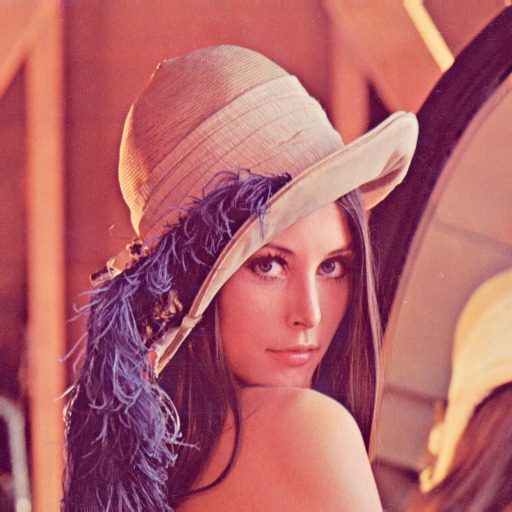

In [ ]:
import cv2 as cv
import urllib.request
from google.colab.patches import cv2_imshow

# Download sample image
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "img.jpg")

img = cv.imread("img.jpg")
cv2_imshow(img)

#Convert to Grayscale

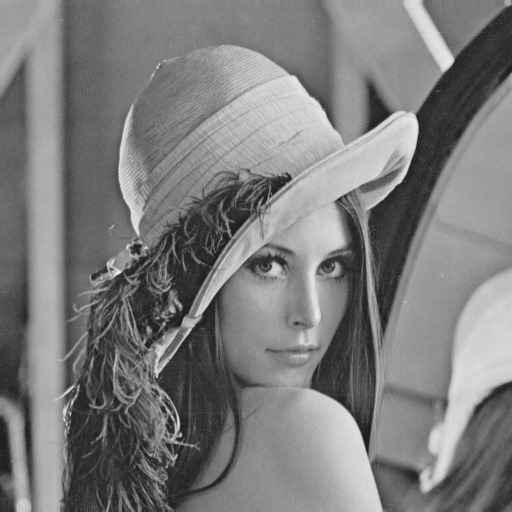

In [ ]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv2_imshow(gray)

#Noise Reduction (Gaussian Blur)

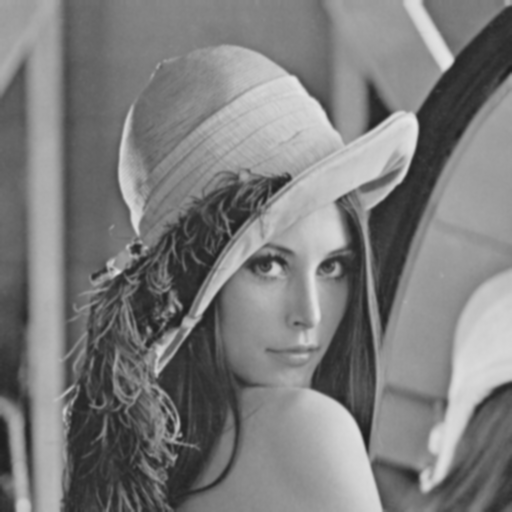

In [ ]:
blur = cv.GaussianBlur(gray, (5,5), 0)
cv2_imshow(blur)

#Canny Edge Detection

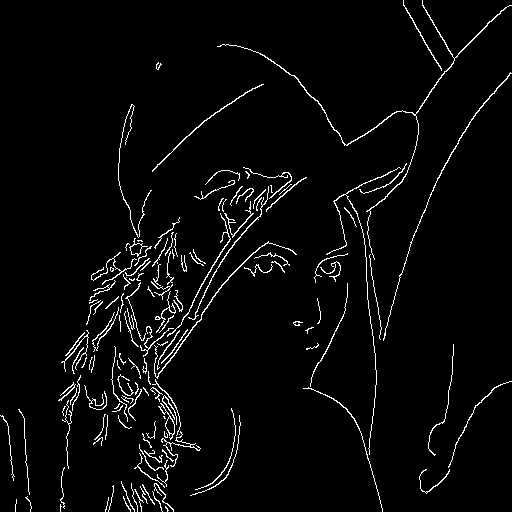

In [ ]:
edges = cv.Canny(blur, 100, 200)
cv2_imshow(edges)

#Sobel Edge Detection

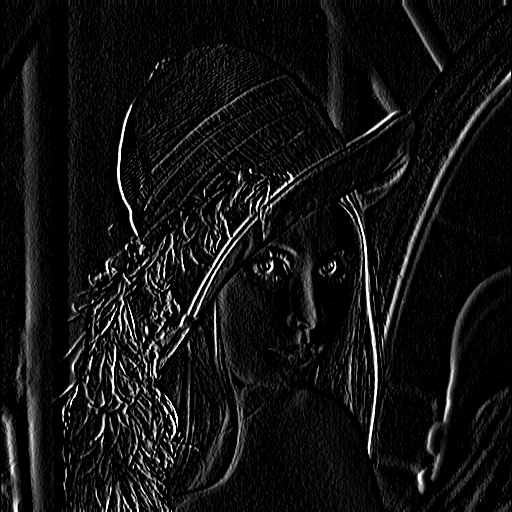

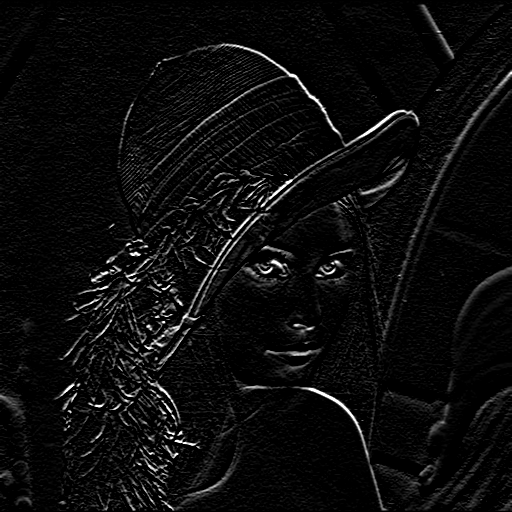

In [ ]:
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)

cv2_imshow(sobelx)
cv2_imshow(sobely)

#Laplacian Edge Detection

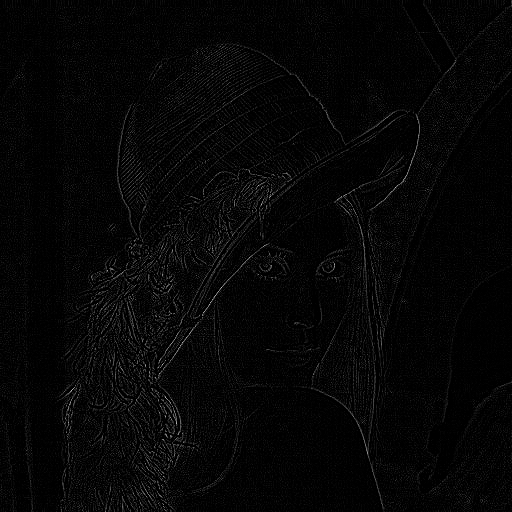

In [ ]:
lap = cv.Laplacian(gray, cv.CV_64F)
cv2_imshow(lap)

#Thresholding

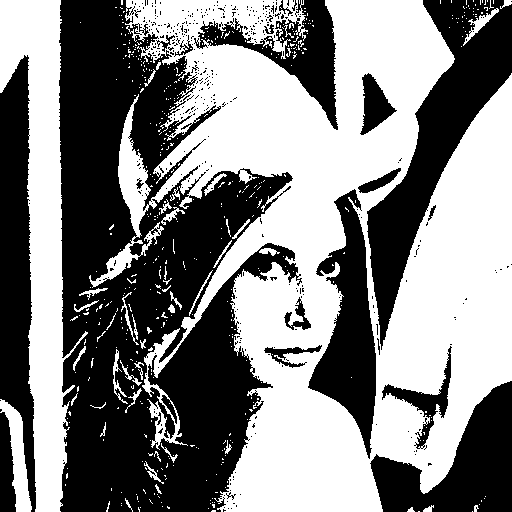

In [ ]:
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
cv2_imshow(thresh)

#Morphological Operations

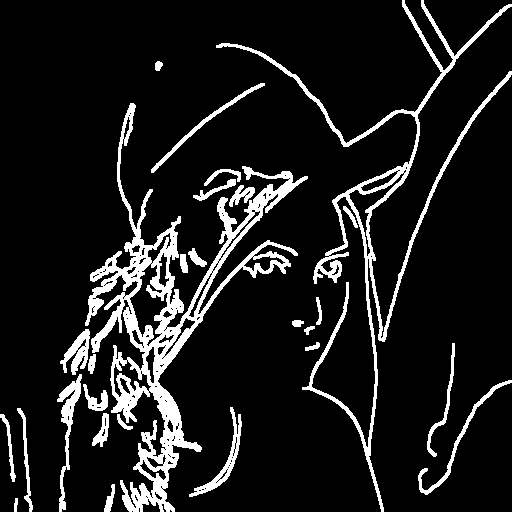

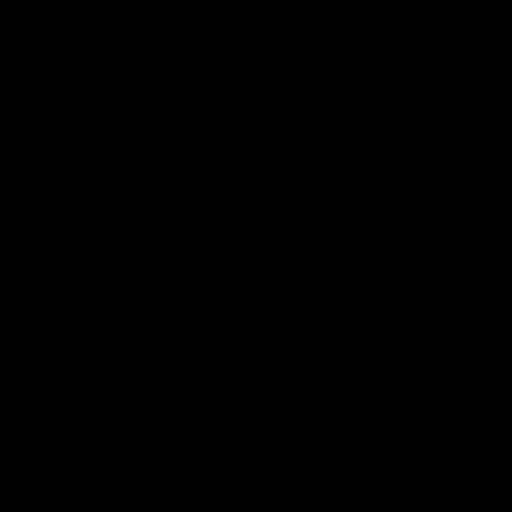

In [ ]:
import numpy as np

kernel = np.ones((3,3), np.uint8)

dilate = cv.dilate(edges, kernel, iterations=1)
erode = cv.erode(edges, kernel, iterations=1)

cv2_imshow(dilate)
cv2_imshow(erode)

In [ ]:
# Step 1: Import necessary libraries
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# Step 2: Upload an image
uploaded = files.upload()

# Step 3: Read the uploaded image
image_path = next(iter(uploaded))
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Step 4: Apply Gaussian Blur to reduce noise
blurred_image = cv2.GaussianBlur(image, (5, 5), 1.4)

# Step 5: Apply Canny edge detector
edges = cv2.Canny(blurred_image, 50, 150)

# Step 6: Display the original image and the edge-detected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Edge Detected Image')
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

KeyboardInterrupt: 

#Image Blurring Using

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image = cv2.imread('geek.png')

blur_filter1 = np.ones((3,3),dtype=np.float32)/9.0
blur_filter2 = np.ones((5,5),dtype=np.float32)/25.0
blur_filter3 = np.ones((7,7),dtype=np.float32)/49.0

image_blur1 = cv2.filter2D(image,-1,blur_filter1)
image_blur2 = cv2.filter2D(image,-1,blur_filter2)
image_blur3 = cv2.filter2D(image,-1,blur_filter3)

cv2_imshow(image)
cv2_imshow(image_blur1)
cv2_imshow(image_blur2)
cv2_imshow(image_blur3)

#Real Time Edge Detection

In [ ]:
import cv2 as cv

cam = cv.VideoCapture(0)

while True:
    ret, frame = cam.read()
    if not ret: # Check if frame was successfully captured
        print("Failed to grab frame, exiting...")
        break
    frame = cv.flip(frame, 1)

    blur = cv.blur(frame, (3, 3))

    edges_original = cv.Canny(frame, 100, 200)
    edges_blur = cv.Canny(blur, 100, 200)

    # cv.imshow and cv.waitKey are not suitable for Colab for interactive video.
    # You can process frames, but displaying them in a loop like this will not work.
    # For displaying static frames, use google.colab.patches.cv2_imshow on a single frame.

    key = cv.waitKey(1)
    if key == 27:  # Escape key
        break

cam.release()
cv.destroyAllWindows()

Failed to grab frame, exiting...


In [ ]:
import cv2 as cv

cap = cv.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Blur
    blur = cv.GaussianBlur(gray, (5,5), 0)

    # Canny Edge Detection
    edges = cv.Canny(blur, 100, 200)

    cv.imshow("Original", frame)
    cv.imshow("Edges", edges)

    # Press 'q' to exit
    if cv.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv.destroyAllWindows()

<IPython.core.display.Javascript object>

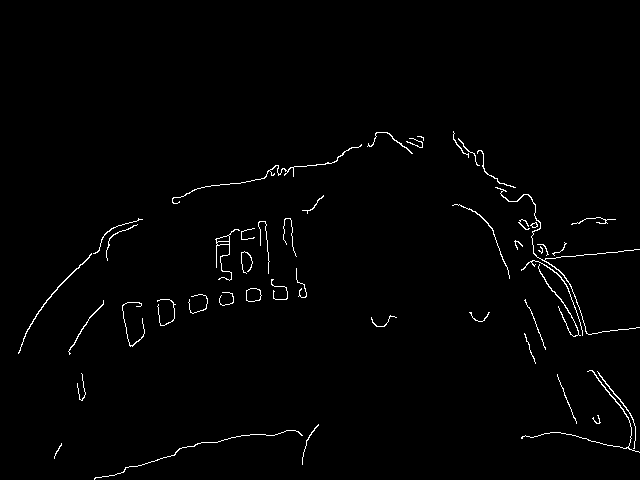

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_frame():
    js = Javascript('''
        async function takePhoto() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();

            return canvas.toDataURL('image/jpeg');
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    np_arr = np.frombuffer(binary, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    return img

# Capture frame
frame = take_frame()

# Edge detection
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 100, 200)

cv2_imshow(edges)